In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
device

device(type='cuda')

In [3]:
def show_dataset_images(dataset, title, num_images=5):
    plt.figure(figsize=(5, 2))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()
    
def show_images(images, title=None):
    """Shows a list of images in a grid.
    
    Args:
        images: List or tensor of images
        title: Optional title for the plot
        num_images: Number of images to show (default 5)
    """
    plt.figure(figsize=(8, 8))
    num_rows = int(np.sqrt(len(images)))
    num_cols = num_rows
    
    for i in range(len(images)):
        plt.subplot(num_rows, num_cols, i + 1)
        if isinstance(images, list):
            img = images[i]
        else:
            img = images[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    if title:
        plt.suptitle(title)
    plt.show()


Training dataset size: 48000
Test dataset size: 12000


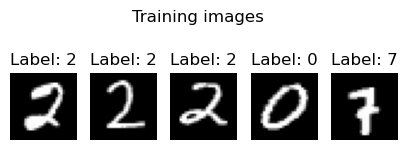

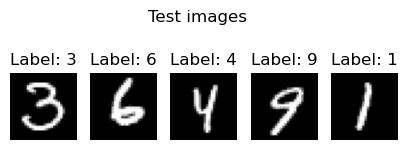

In [4]:
# Import dataset.

def uniform_dequantize(x):
    u = torch.rand_like(x)
    x_deq = (x * 255.0 + u)/256.0
    return x_deq

mnist_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(uniform_dequantize)
])

dataset = datasets.MNIST('./data', train=True, transform=mnist_transforms, download=True)
train_ratio = 0.8
train_size = int(len(dataset) * train_ratio)
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Training dataset size: {len(train_dataset.indices)}")
print(f"Test dataset size: {len(test_dataset.indices)}")

show_dataset_images(train_dataset, 'Training images')
show_dataset_images(test_dataset, 'Test images')

In [5]:
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, num_workers=2)

In [6]:
import torch.nn as nn

class AffineCoupling(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.network = nn.Sequential(
            nn.Linear(input_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim , hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def forward(self, x):
        # Divide x into two parts, x_a, x_b
        x_a, x_b = x.chunk(2, dim=1)
        # Pass through the network to get params for affine coupling layer
        s, t = self.network(x_a).chunk(2, dim=1)
        s = torch.tanh(s)
        
        # Just copy over x_a to z_a
        z_a = x_a
        # Affline coupling.
        z_b = x_b * torch.exp(s) + t
        log_det = s.sum(dim=1)
        
        return torch.cat([z_a, z_b], dim=1), log_det
    
    def inverse(self, z):
        # Divide x into two parts, z_a, z_b. z_a is same as x_a
        z_a, z_b = z.chunk(2, dim=1)
        # Pass z_a through the network.
        s, t = self.network(z_a).chunk(2, dim=1)
        s = torch.tanh(s)
        
        x_a = z_a
        x_b = (z_b - t) * torch.exp(-s)
        return torch.cat([x_a, x_b], dim=1)


class Flip(nn.Module):
    def __init__(self, flip_dims):
        super().__init__()
        self.flip_dims = flip_dims
    
    def forward(self, x):
        return torch.flip(x, dims=self.flip_dims), 0
    
    def inverse(self, z):
        return torch.flip(z, dims=self.flip_dims)


class SimpleFlow(nn.Module):
    def __init__(self, n_blocks, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.n_blocks = n_blocks
        self.layers = []
        for i in range(n_blocks):
            self.layers.append(AffineCoupling(input_dim, hidden_dim))
            self.layers.append(Flip([1]))
        self.layers = nn.ModuleList(self.layers)
    
    def forward(self, x):
        log_det_sum = 0
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_sum += log_det
        return x, log_det_sum
    
    def inverse(self, z):
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z

In [9]:
import torch.optim as optim

input_dim = 28 * 28
hidden_dim = 512
num_blocks = 8

model = SimpleFlow(num_blocks, input_dim = input_dim, hidden_dim=hidden_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 20

model.train()
for epoch in range(num_epochs):
    for data, batch_idx in train_loader:
        x = data.view(-1, input_dim).to(device)
        z, log_det = model(x)
        
        # Standard normal log probability distribution.
        log_prob = -0.5 * (z ** 2).sum(dim=1) - 0.5 * input_dim * np.log(2 * np.pi)
        loss = -(log_prob + log_det).mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch({epoch}/{num_epochs}), loss:{loss:.4f}")

Epoch(0/20), loss:-1532.2689
Epoch(1/20), loss:-1630.9761
Epoch(2/20), loss:-1682.5027
Epoch(3/20), loss:-1772.3804
Epoch(4/20), loss:-1786.5471
Epoch(5/20), loss:-1821.0793
Epoch(6/20), loss:-1852.8782
Epoch(7/20), loss:-1838.5229
Epoch(8/20), loss:-1840.4004
Epoch(9/20), loss:-1879.5701
Epoch(10/20), loss:-1882.6372
Epoch(11/20), loss:-1891.8389
Epoch(12/20), loss:-1937.8601
Epoch(13/20), loss:-1912.6494
Epoch(14/20), loss:-1920.8123
Epoch(15/20), loss:-1923.5835
Epoch(16/20), loss:-1899.6304
Epoch(17/20), loss:-1933.9438
Epoch(18/20), loss:-1943.8586
Epoch(19/20), loss:-1945.0349


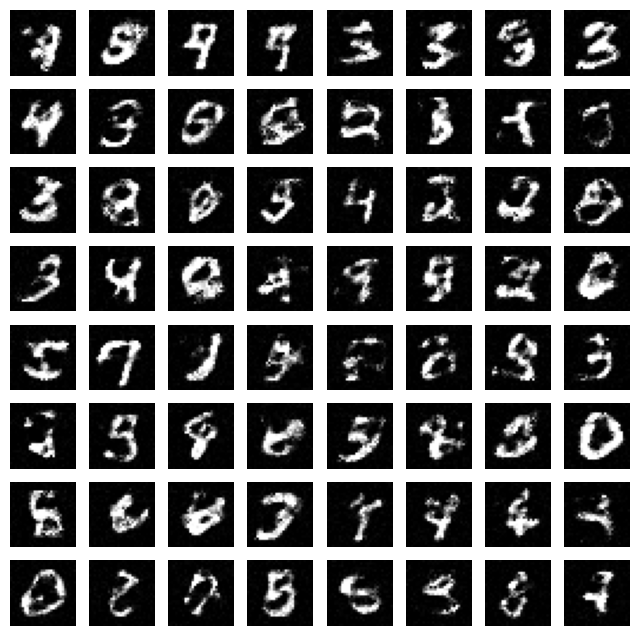

In [8]:
# Sampling and eval.
model.eval()
with torch.no_grad():
    z = torch.randn(64, input_dim).to(device)
    samples = model.inverse(z).cpu()
    samples = samples.clamp(0, 1).view(-1, 1, 28, 28)
    show_images(samples)
